In [37]:
import numpy as np 
from uncertainties import ufloat
import pandas as pd 
import matplotlib.pyplot as plt

In [38]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [39]:
mcmc_fit_data = pd.read_csv("mcmc_fit_adjusted.csv", index_col = 0)
bell_data = pd.read_csv("bell_final_data.csv")

In [40]:
mcmc_fit_data

,Median Value,Uncertainty,2-sigma Uncertainty,Uncertainty/Value
Phase,-1.497916,0.406991,0.813982,-0.543409
Amplitude,674.252396,4.651664,9.303328,0.013798
Baseline,812.723106,3.717995,7.435990,0.009149


In [41]:
center_line = ufloat(mcmc_fit_data["Median Value"].to_numpy()[2], mcmc_fit_data["Uncertainty"].to_numpy()[2])
amplitude = ufloat(mcmc_fit_data["Median Value"].to_numpy()[1], mcmc_fit_data["Uncertainty"].to_numpy()[1])

background = center_line - amplitude
background

138.47070921417026+/-5.954952968155355

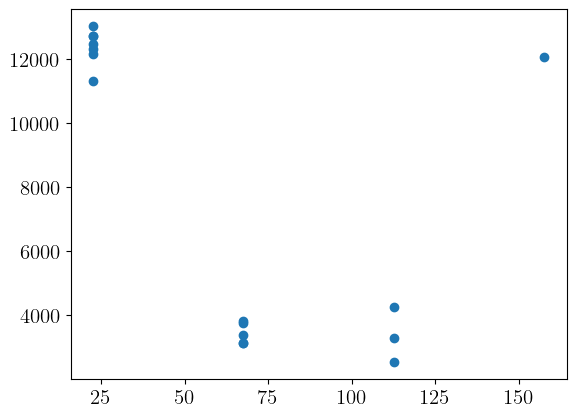

In [42]:
plt.scatter(np.abs(bell_data["ANGLE_B"] - bell_data["ANGLE_A"]), bell_data["N_COIN"])

In [43]:
raw_counts = bell_data["N_COIN"].to_numpy()
raw_rate = np.array([ufloat(i, np.sqrt(i)) for i in raw_counts]) / bell_data["TIME"].to_numpy()
raw_rate -= background

#include this if you want to inflate the error bound
chi_sq_uncertainty_multiplier = np.sqrt(6.7895013760816525)
for i in range(len(raw_rate)):
    raw_rate[i] = ufloat(raw_rate[i].nominal_value, raw_rate[i].std_dev * chi_sq_uncertainty_multiplier)

raw_rate

array([993.7301563509893+/-31.782915803125896,
       1081.0512775096904+/-32.7379522817505,
       285.6237775575017+/-22.993497589774,
       237.42515593131316+/-22.270550205475992,
       243.22242030949832+/-22.358703061765937,
       198.5259208195294+/-21.669501257195282,
       1066.1749231947606+/-32.547972768431,
       1109.3366620255529+/-33.00705987702198,
       1133.0087768695148+/-33.23808623341489,
       1130.7544065040022+/-33.203243692380504,
       174.2249130471181+/-21.285380615718523,
       116.79213599484319+/-20.37845959477085,
       1166.878253005324+/-33.60930245753801,
       1091.462874372316+/-32.79914860546979,
       188.52536683291714+/-21.512253045881142,
       176.00665982532257+/-21.31826924009351], dtype=object)

In [44]:
def E(rates, start):
    return (rates[start] + rates[start + 1] - rates[start + 2] - rates[start + 3])/np.sum(rates[start:start+4])

In [45]:
bell_data

,TRIAL_NO,ORIENT,ARGUMENT_1,ARGUMENT_2,ANGLE_A,ANGLE_B,N_A,N_B,N_COIN,TIME,N_ACTUAL
0,1,N(VV),A,B,-45,-22.5,418879,275446,11312,9.99116,11124.8
1,2,N(HH),A+90,B+90,45,67.5,420169,270848,12151,9.96374,11965.9
2,3,N(VH),A,B+90,-45,67.5,420894,273547,4241,10.00013,4054.4
3,4,N(HV),A+90,B,45,-22.5,421810,275305,3759,10.00011,3570.8
4,5,N(VV),A,B_PRIME,-45,22.5,419836,293497,3817,10.00018,3617.3
5,6,N(HH),A + 90,B_PRIME + 90,45,112.5,420581,254665,3370,10.00010,3196.4
6,7,N(VH),A,B_PRIME + 90,-45,112.5,419636,254455,12036,9.99132,11862.8
7,8,N(HV),A + 90,B_PRIME,45,22.5,420469,292662,12456,9.98231,12256.2
8,9,N(VV),A_PRIME,B,0,-22.5,441672,273289,12704,9.99151,12508.2
9,10,N(HH),A_PRIME + 90,B + 90,90,67.5,401713,276152,12693,10.00059,12513.2


In [46]:
E1 = E(raw_rate,0)
E2 = E(raw_rate,4)
E3 = E(raw_rate,8)
E4 = E(raw_rate,12)
S = E1 - E2 + E3 + E4

In [47]:
for i, e in enumerate([E1, E2, E3, E4]):
    print(f"E{i+1}:", e)

E1: 0.597+/-0.021
E2: -0.662+/-0.021
E3: 0.772+/-0.021
E4: 0.722+/-0.020


In [48]:
print("S:", S)

S: 2.75+/-0.04
